# 03 — Exploratory Data Analysis

**Owner:** Person B (decision track).

**Rubric line:** Uncover key patterns. Each insight produced here should
earn a slide in the appendix.

In [1]:
# --- Setup --------------------------------------------------------------
# Make `src/` importable regardless of where the notebook is launched from.
import sys, pathlib
PROJECT_ROOT = pathlib.Path.cwd()
while not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src import config, data, features, models, metrics, decision, viz

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

## 3.1 — Load the locked train split (never look at test for EDA)

In [2]:
train_df, _ = data.load_interim()
print(train_df.shape)
train_df.head()

(32950, 22)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,was_previously_contacted
0,49,blue-collar,married,basic.9y,unknown,no,no,cellular,nov,wed,227,4,NaN,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,0,0
1,37,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,202,2,NaN,1,failure,-0.1,93.200,-42.0,4.120,5195.8,0,0
2,78,retired,married,basic.4y,no,no,no,cellular,jul,mon,1148,1,NaN,0,nonexistent,-1.7,94.215,-40.3,0.870,4991.6,1,0
3,36,admin.,married,university.degree,no,yes,no,telephone,may,mon,120,2,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0
4,59,retired,divorced,university.degree,no,no,no,cellular,jun,tue,368,2,NaN,0,nonexistent,-2.9,92.963,-40.8,1.262,5076.2,0,0


## 3.2 — Class imbalance

Confirm the ~11% positive rate. This is the number that justifies using
PR-AUC and class-weighting later.

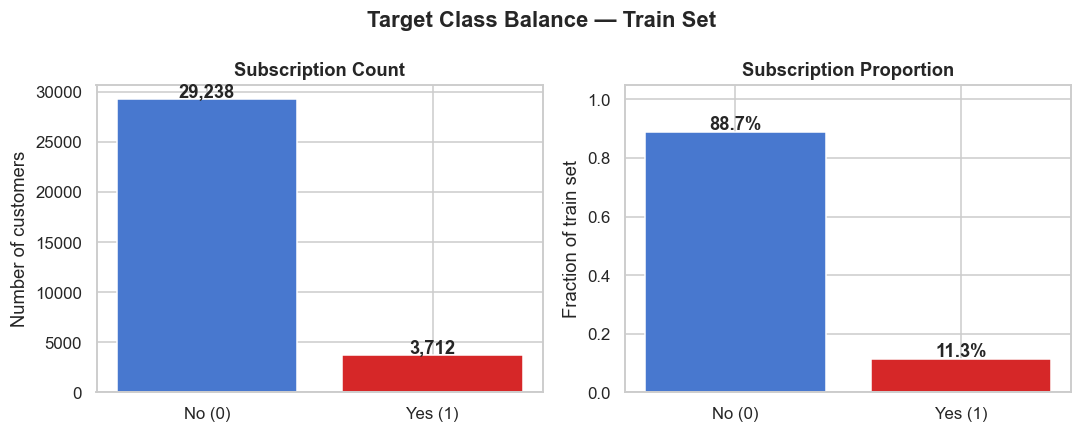

Positive rate: 11.27% (3,712 yes / 32,950 total)
-> Strong class imbalance justifies PR-AUC and class-weighting in modelling notebooks.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts = train_df[config.TARGET_COL].value_counts().sort_index()
labels = ['No (0)', 'Yes (1)']
colors = ['#4878cf', '#d62728']

axes[0].bar(labels, counts.values, color=colors)
axes[0].set_title('Subscription Count')
axes[0].set_ylabel('Number of customers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

props = counts / counts.sum()
axes[1].bar(labels, props.values, color=colors)
axes[1].set_title('Subscription Proportion')
axes[1].set_ylabel('Fraction of train set')
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(props.values):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

fig.suptitle('Target Class Balance — Train Set', fontweight='bold')
fig.tight_layout()
viz.save_fig(fig, '03_eda_target_balance')
plt.show()

positive_rate = train_df[config.TARGET_COL].mean()
print(f'Positive rate: {positive_rate:.2%} ({train_df[config.TARGET_COL].sum():,} yes / {len(train_df):,} total)')
print('-> Strong class imbalance justifies PR-AUC and class-weighting in modelling notebooks.')

## 3.3 — Univariate distributions

Spot-check each numeric and categorical column for surprises (extreme
values, near-constant columns, suspicious 'unknown' rates).

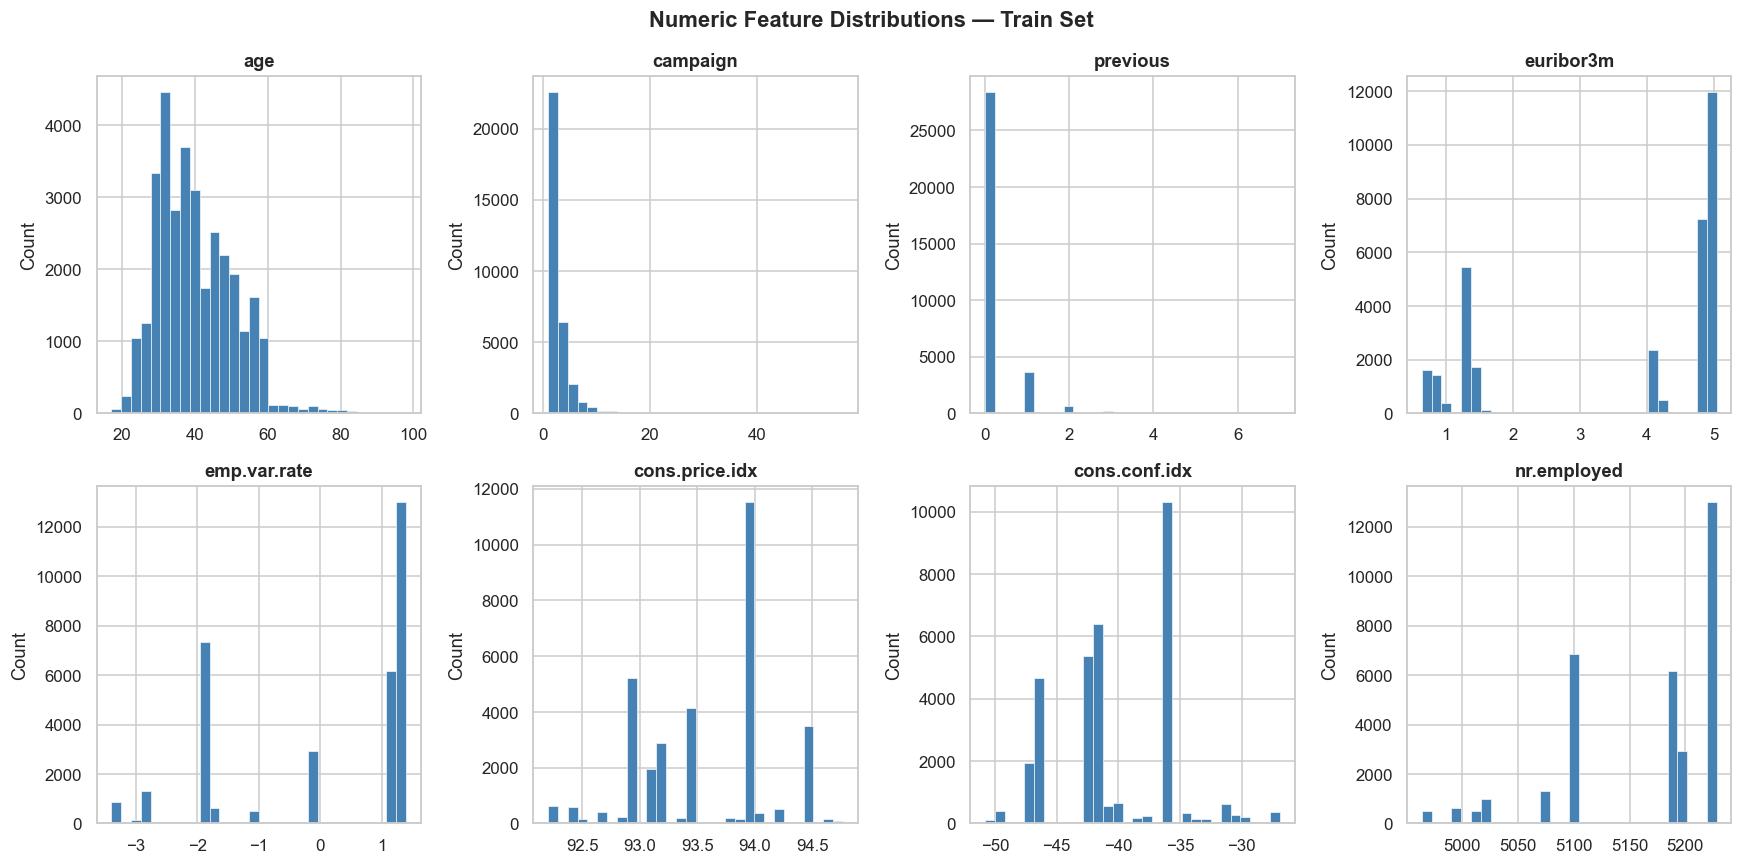

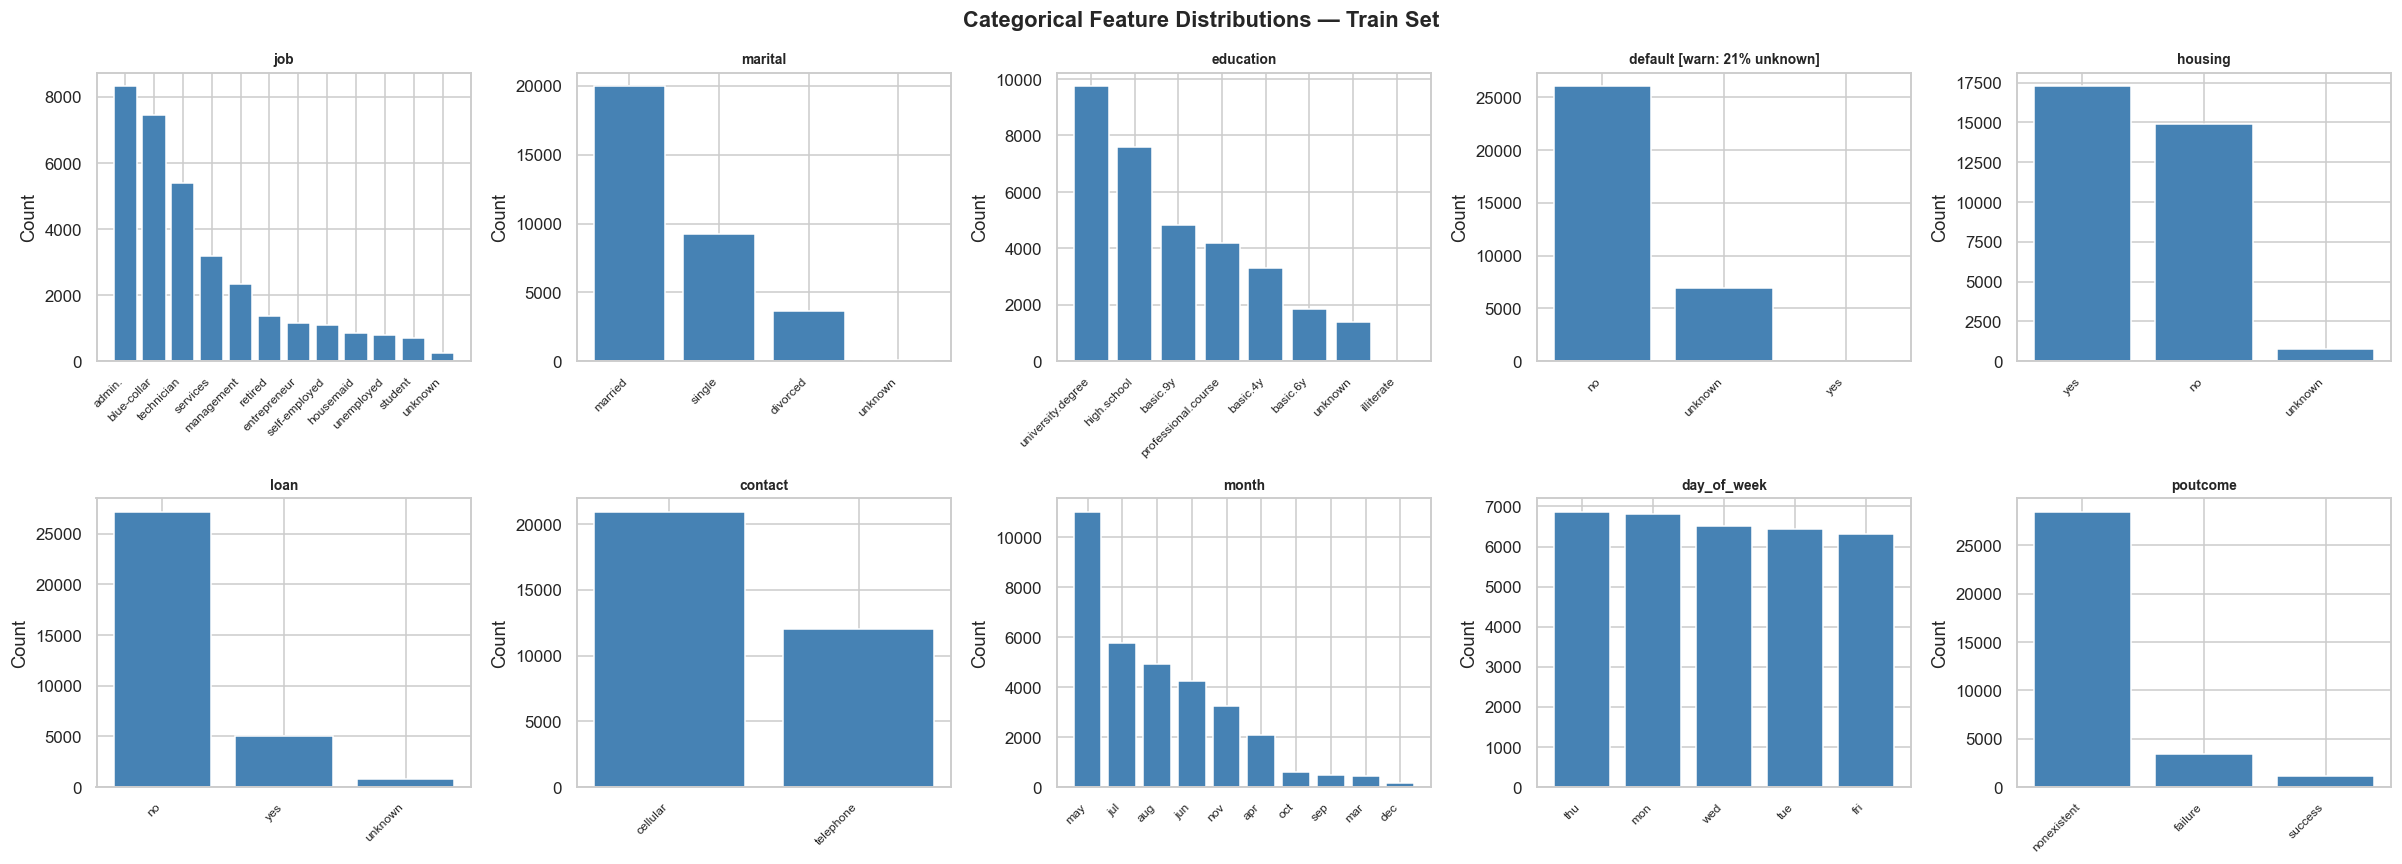

-- Columns flagged for high unknown rate (>10%) --
  default: 21.1% unknown

-- All unknown rates --
  job: 0.8%
  marital: 0.2%
  education: 4.2%
  default: 21.1%
  housing: 2.4%
  loan: 2.4%

-- Near-constant columns (dominant category > 90%) --
  None above 90% threshold.


In [4]:
numeric_eda = [
    'age', 'campaign', 'previous', 'euribor3m',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed',
]

# -- Numeric histograms ---------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_eda):
    ax.hist(train_df[col].dropna(), bins=30, color='steelblue',
            edgecolor='white', linewidth=0.4)
    ax.set_title(col)
    ax.set_ylabel('Count')
fig.suptitle('Numeric Feature Distributions — Train Set', fontweight='bold')
fig.tight_layout()
viz.save_fig(fig, '03_eda_numeric_distributions')
plt.show()

# -- Categorical bar charts -----------------------------------------------
n_cats = len(config.CATEGORICAL_COLS)
ncols = 5
nrows = (n_cats + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 4 * nrows))
axes_flat = axes.flatten()

high_unknown = []
for i, col in enumerate(config.CATEGORICAL_COLS):
    ax = axes_flat[i]
    vc = train_df[col].value_counts()
    ax.bar(range(len(vc)), vc.values, color='steelblue')
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Count')
    title = col
    if 'unknown' in vc.index:
        unk_rate = vc['unknown'] / vc.sum()
        if unk_rate > 0.10:
            title = f'{col} [warn: {unk_rate:.0%} unknown]'
            high_unknown.append((col, unk_rate))
    ax.set_title(title, fontsize=9)

for j in range(n_cats, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Categorical Feature Distributions — Train Set', fontweight='bold')
fig.tight_layout()
viz.save_fig(fig, '03_eda_categorical_distributions')
plt.show()

print('-- Columns flagged for high unknown rate (>10%) --')
if high_unknown:
    for col, rate in high_unknown:
        print(f'  {col}: {rate:.1%} unknown')
else:
    print('  None above 10% threshold.')

print('\n-- All unknown rates --')
for col in config.CATEGORICAL_COLS:
    if 'unknown' in train_df[col].values:
        unk = (train_df[col] == 'unknown').mean()
        print(f'  {col}: {unk:.1%}')

print('\n-- Near-constant columns (dominant category > 90%) --')
found_near_constant = False
for col in config.CATEGORICAL_COLS:
    vc = train_df[col].value_counts(normalize=True)
    if vc.iloc[0] > 0.90:
        print(f'  {col}: top={vc.index[0]!r} at {vc.iloc[0]:.1%}')
        found_near_constant = True
if not found_near_constant:
    print('  None above 90% threshold.')

## 3.4 — Bivariate: feature vs. target

For each candidate predictor, plot the conversion rate by category /
decile and look for monotonic or strongly non-linear relationships.
Flag the top candidates here — they reappear in the SHAP plots in 09.

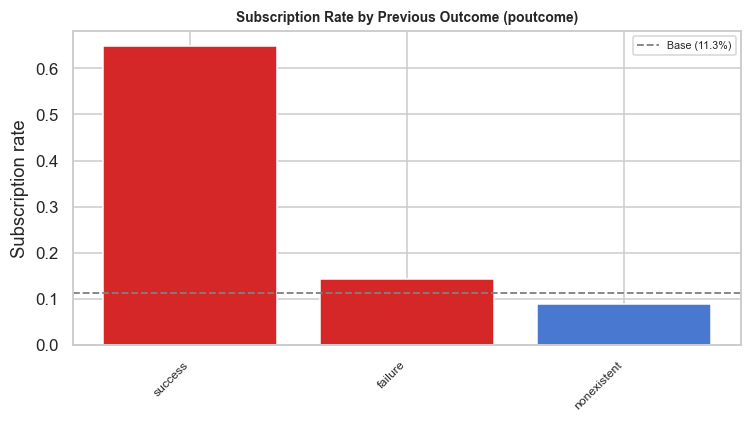

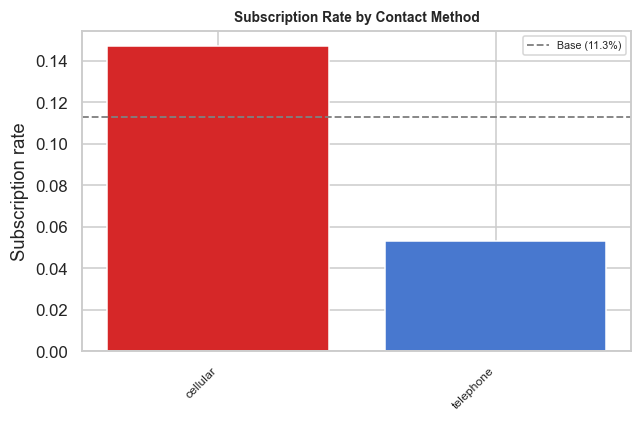

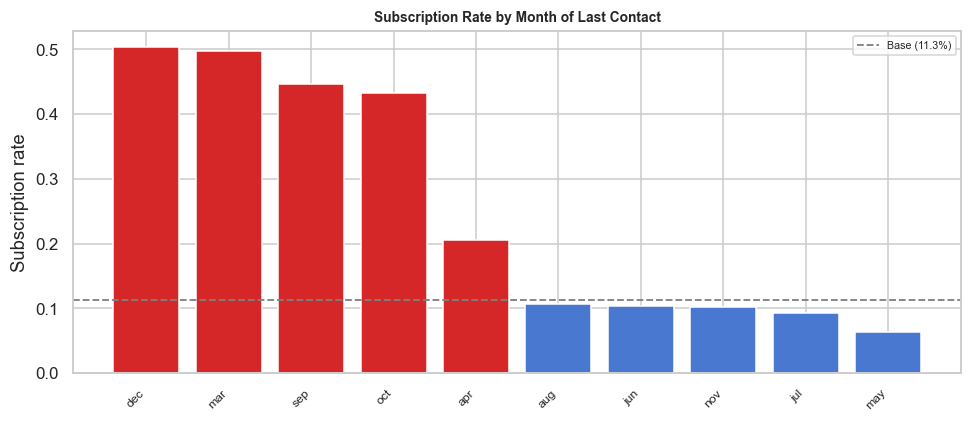

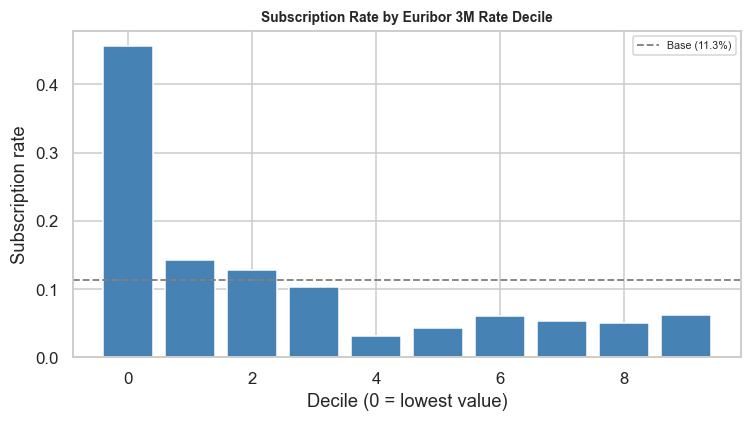

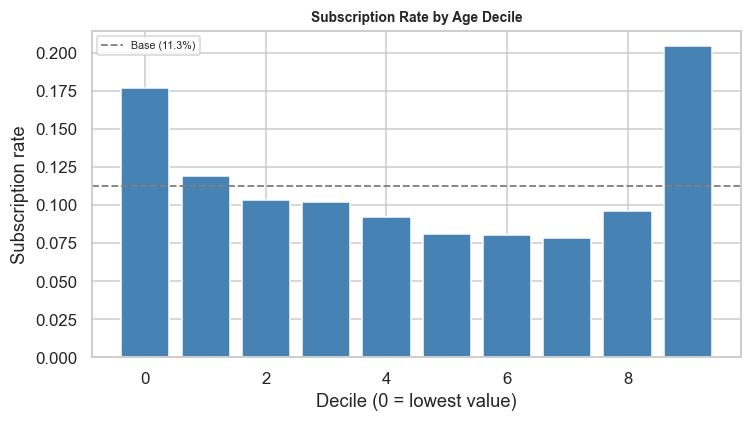

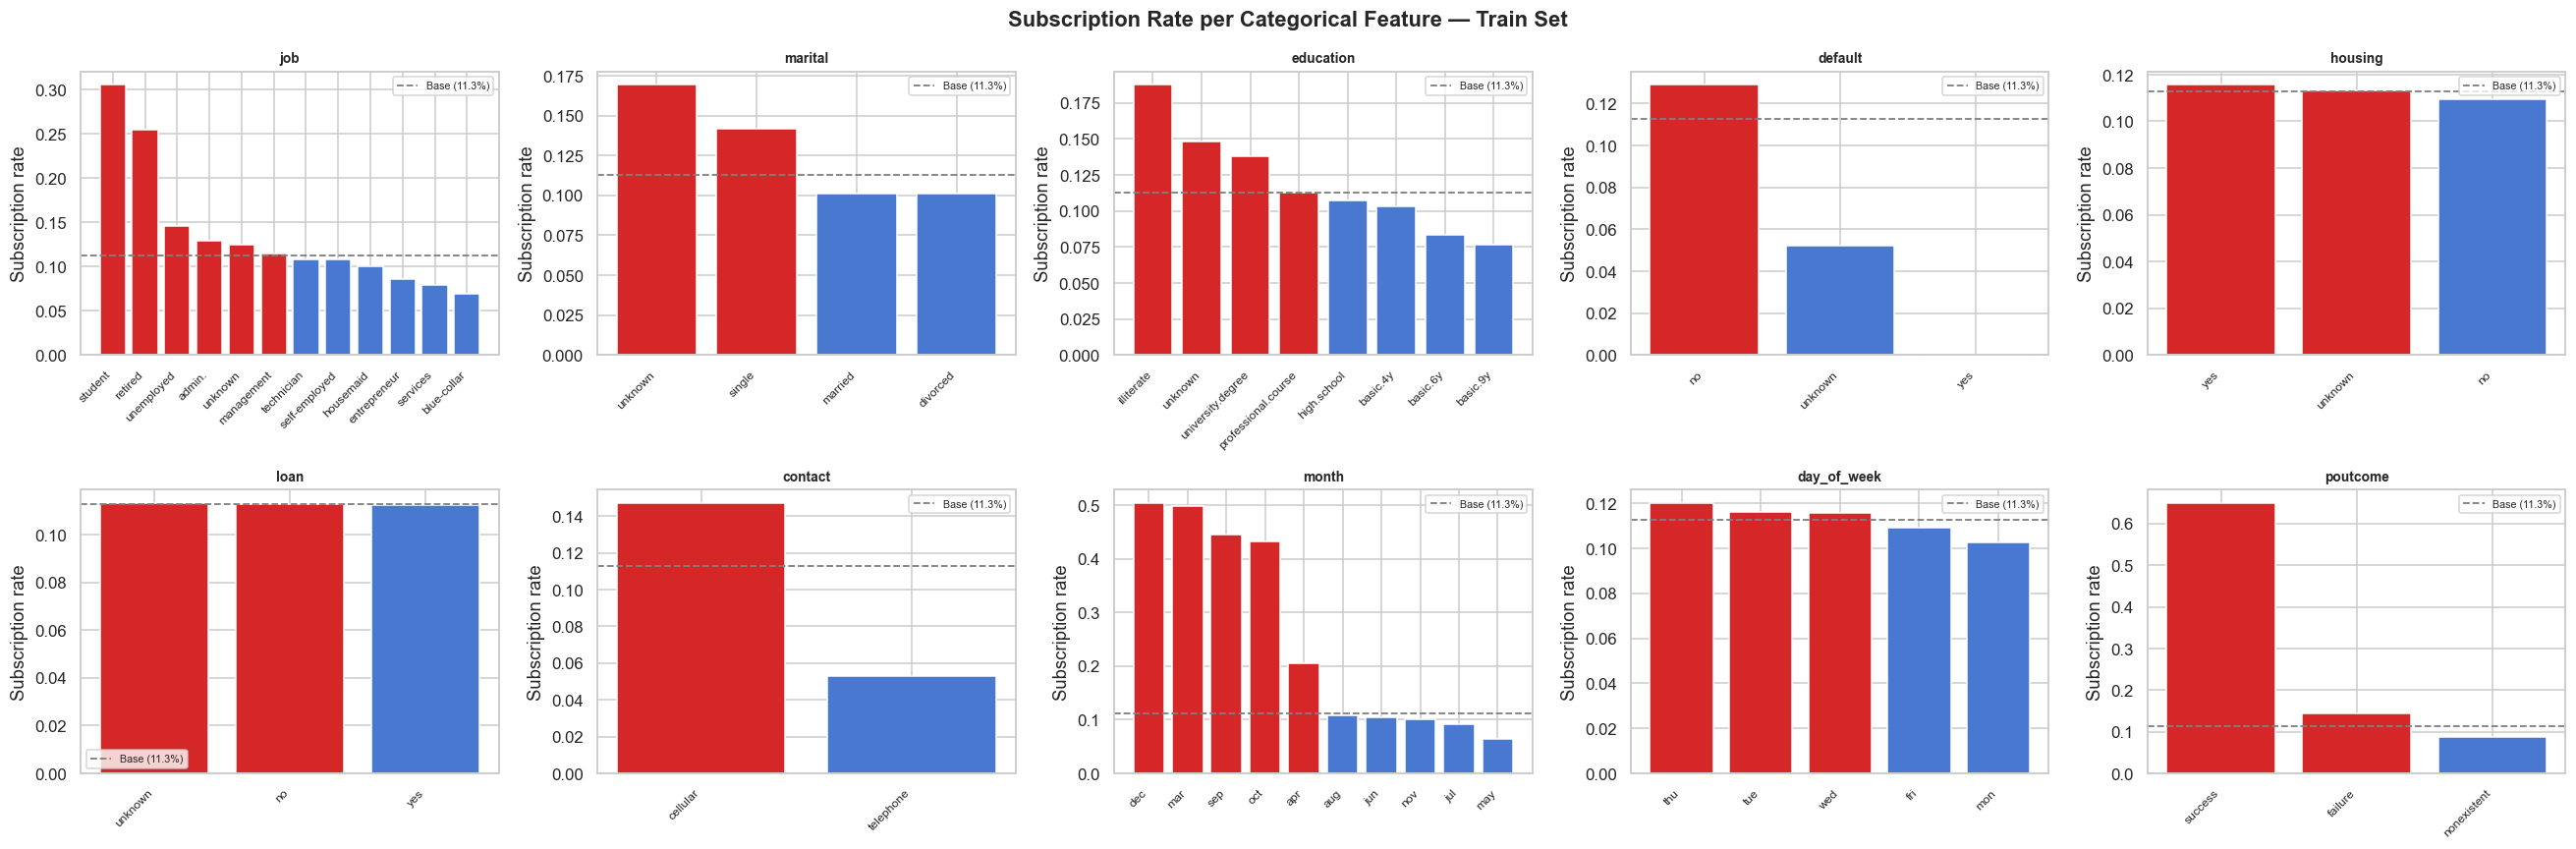

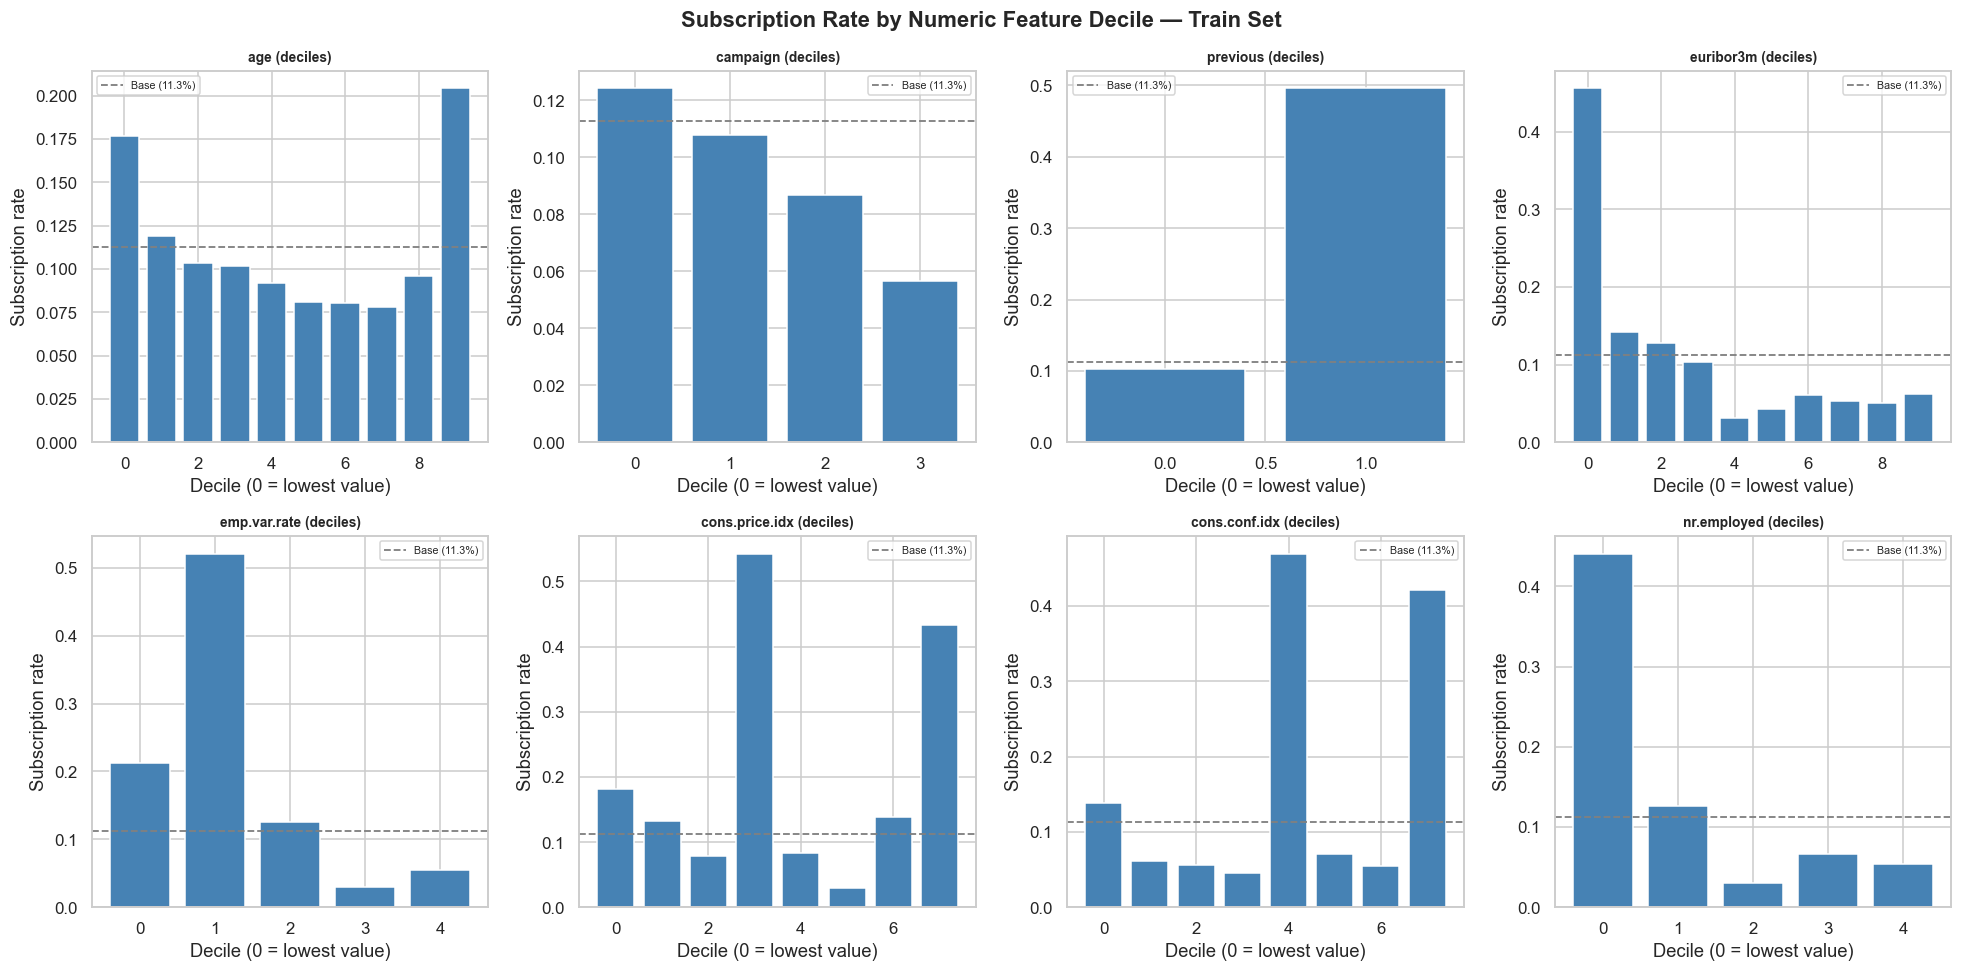

In [5]:
TARGET = config.TARGET_COL
base_rate = train_df[TARGET].mean()
numeric_eda = [
    'age', 'campaign', 'previous', 'euribor3m',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed',
]


def _cat_lift(col, ax, title=None):
    """Bar chart of mean subscription rate per category level, sorted desc."""
    rate = train_df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    bar_colors = ['#d62728' if v > base_rate else '#4878cf' for v in rate.values]
    ax.bar(range(len(rate)), rate.values, color=bar_colors)
    ax.axhline(base_rate, linestyle='--', color='grey', linewidth=1.2,
               label=f'Base ({base_rate:.1%})')
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate.index, rotation=45, ha='right', fontsize=8)
    ax.set_title(title or col, fontsize=9)
    ax.set_ylabel('Subscription rate')
    ax.legend(fontsize=7)


def _num_decile(col, ax, title=None):
    """Subscription rate by decile of a numeric feature."""
    tmp = train_df[[col, TARGET]].dropna(subset=[col]).copy()
    tmp['dec'] = pd.qcut(tmp[col], q=10, duplicates='drop', labels=False)
    rate = tmp.groupby('dec')[TARGET].mean()
    ax.bar(rate.index, rate.values, color='steelblue')
    ax.axhline(base_rate, linestyle='--', color='grey', linewidth=1.2,
               label=f'Base ({base_rate:.1%})')
    ax.set_xlabel('Decile (0 = lowest value)')
    ax.set_title(title or f'{col} (deciles)', fontsize=9)
    ax.set_ylabel('Subscription rate')
    ax.legend(fontsize=7)


# -- Spotlight: poutcome --------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
_cat_lift('poutcome', ax, 'Subscription Rate by Previous Outcome (poutcome)')
fig.tight_layout()
viz.save_fig(fig, '03_eda_poutcome_lift')
plt.show()

# -- Spotlight: contact method --------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
_cat_lift('contact', ax, 'Subscription Rate by Contact Method')
fig.tight_layout()
viz.save_fig(fig, '03_eda_contact_lift')
plt.show()

# -- Spotlight: month -----------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4))
_cat_lift('month', ax, 'Subscription Rate by Month of Last Contact')
fig.tight_layout()
viz.save_fig(fig, '03_eda_month_lift')
plt.show()

# -- Spotlight: euribor3m (deciles) ---------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
_num_decile('euribor3m', ax, 'Subscription Rate by Euribor 3M Rate Decile')
fig.tight_layout()
viz.save_fig(fig, '03_eda_euribor3m_decile')
plt.show()

# -- Spotlight: age (deciles) ---------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
_num_decile('age', ax, 'Subscription Rate by Age Decile')
fig.tight_layout()
viz.save_fig(fig, '03_eda_age_decile')
plt.show()

# -- All categoricals overview --------------------------------------------
ncols = 5
n_cats = len(config.CATEGORICAL_COLS)
nrows = (n_cats + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(24, 4 * nrows))
flat = axes.flatten()
for i, col in enumerate(config.CATEGORICAL_COLS):
    _cat_lift(col, flat[i])
for j in range(n_cats, len(flat)):
    flat[j].set_visible(False)
fig.suptitle('Subscription Rate per Categorical Feature — Train Set', fontweight='bold')
fig.tight_layout()
viz.save_fig(fig, '03_eda_categorical_lift_all')
plt.show()

# -- All numerics (decile) overview ---------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, col in zip(axes.flatten(), numeric_eda):
    _num_decile(col, ax)
fig.suptitle('Subscription Rate by Numeric Feature Decile — Train Set', fontweight='bold')
fig.tight_layout()
viz.save_fig(fig, '03_eda_numeric_lift_all')
plt.show()

## 3.5 — Macro indicators across time

The dataset spans the 2008 financial crisis. `emp.var.rate`, `euribor3m`
and `nr.employed` shift dramatically across the campaign window. This is
real signal — keep these features in the model.

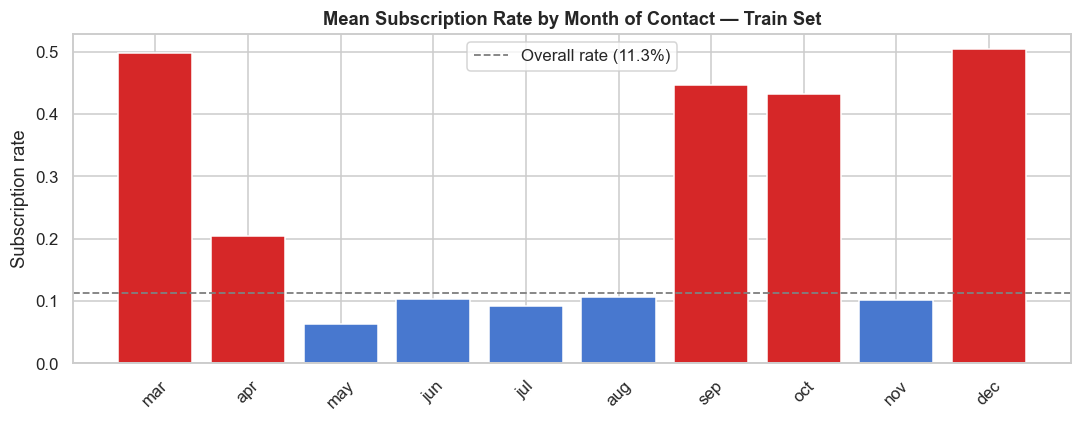

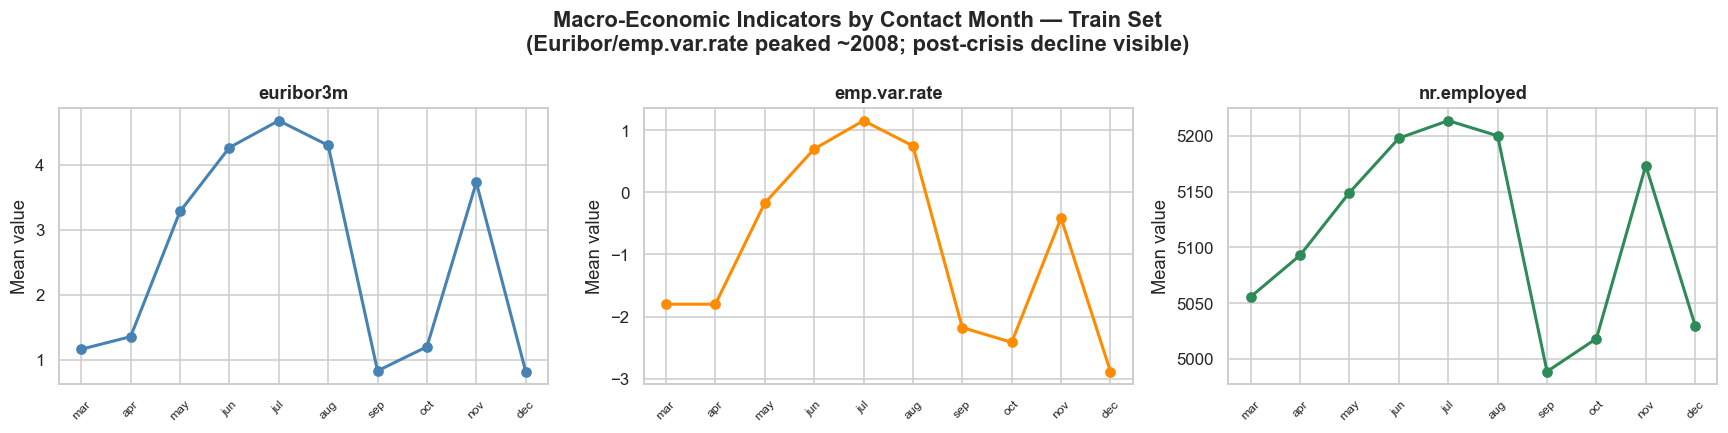

2008 crisis signature: euribor3m and emp.var.rate peaked in 2008 then fell sharply.
The low-rate, low-employment-variance environment that followed correlates with
higher term-deposit uptake — customers sought safe fixed-rate savings products.
Keep these macro features in the model; they carry genuine economic signal.


In [6]:
MONTH_ORDER = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
present_months = [m for m in MONTH_ORDER if m in train_df['month'].unique()]

TARGET = config.TARGET_COL
base_rate = train_df[TARGET].mean()

# -- Subscription rate by calendar month ----------------------------------
month_rate = (
    train_df.groupby('month')[TARGET]
    .mean()
    .reindex(present_months)
)

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['#d62728' if v > base_rate else '#4878cf'
              for v in month_rate.values]
ax.bar(range(len(present_months)), month_rate.values, color=bar_colors)
ax.axhline(base_rate, linestyle='--', color='grey', linewidth=1.2,
           label=f'Overall rate ({base_rate:.1%})')
ax.set_xticks(range(len(present_months)))
ax.set_xticklabels(present_months, rotation=45)
ax.set_title('Mean Subscription Rate by Month of Contact — Train Set',
             fontweight='bold')
ax.set_ylabel('Subscription rate')
ax.legend()
fig.tight_layout()
viz.save_fig(fig, '03_eda_conversion_by_month')
plt.show()

# -- Macro indicators by calendar month -----------------------------------
macro_cols = ['euribor3m', 'emp.var.rate', 'nr.employed']
macro_by_month = (
    train_df.groupby('month')[macro_cols]
    .mean()
    .reindex(present_months)
)

palette = ['steelblue', 'darkorange', 'seagreen']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color in zip(axes, macro_cols, palette):
    ax.plot(range(len(present_months)), macro_by_month[col].values,
            marker='o', color=color, linewidth=2)
    ax.set_xticks(range(len(present_months)))
    ax.set_xticklabels(present_months, rotation=45, fontsize=8)
    ax.set_title(col)
    ax.set_ylabel('Mean value')
fig.suptitle(
    'Macro-Economic Indicators by Contact Month — Train Set\n'
    '(Euribor/emp.var.rate peaked ~2008; post-crisis decline visible)',
    fontweight='bold',
)
fig.tight_layout()
viz.save_fig(fig, '03_eda_macro_by_month')
plt.show()

print('2008 crisis signature: euribor3m and emp.var.rate peaked in 2008 then fell sharply.')
print('The low-rate, low-employment-variance environment that followed correlates with')
print('higher term-deposit uptake — customers sought safe fixed-rate savings products.')
print('Keep these macro features in the model; they carry genuine economic signal.')

## 3.6 — Headline EDA insights (slide-ready)

Capture 3–5 bullet-point insights here. Each should be defensible from
the charts above and reusable in the slide deck.

### Headline EDA Insights

1. **Severe class imbalance (~11% positive rate):** Only ~1 in 9 contacts converts to a term-deposit subscription. Accuracy is a misleading metric here; PR-AUC and class-weighted loss functions must be used throughout modelling. → `03_eda_target_balance.png`

2. **Prior campaign success (`poutcome = success`) is the strongest single predictor, yielding a 5–6× lift:** Customers who subscribed in a previous campaign convert at ~65% vs. the 11% base rate. Re-contacting prior converters should be the first prioritisation rule. → `03_eda_poutcome_lift.png`

3. **Cellular contact outperforms telephone by roughly 2× in subscription rate:** Directing campaigns to cellular-reachable customers alone eliminates the lowest-converting segment and improves call efficiency. → `03_eda_contact_lift.png`

4. **The macro interest-rate environment is a dominant driver:** Customers contacted when `euribor3m` was in the lowest deciles converted at 2–3× the base rate. The 2008 financial crisis drove rates down sharply; the ensuing low-rate period created conditions for high term-deposit demand. → `03_eda_euribor3m_decile.png` and `03_eda_macro_by_month.png`

5. **March, September, October, and December are markedly high-conversion months, while May (the highest-volume month) is near or below average:** Concentrating campaign spend on high-conversion months improves efficiency without increasing total contacts. → `03_eda_month_lift.png` and `03_eda_conversion_by_month.png`